<a href="https://colab.research.google.com/github/muvunyiy77-a11y/Day-One/blob/main/titanic_survival_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Group Members

Names + Reg Numbers

1.   Yannick Muvunyi: BBICTE242500001
2.   Jimmy Mulisa: BBICTR/2025/32490
3.   Kayonga Bruce: BBICTR/2025/69786





# Titanic Survival Analysis
### An End-to-End Data Analysis Lifecycle Project

**Author:** Data Analysis Notebook
**Dataset:** Titanic passenger manifest (`seaborn-data`, sourced originally from Kaggle / Encyclopedia Titanica)
**Date:** 2026-07-16

This notebook follows the full data analysis lifecycle:

1. Ask (SMART Questions)
2. Data Collection
3. Data Cleaning
4. Data Exploration (EDA)
5. Statistical Analysis
6. Visualization
7. Communication of Outcomes (Decision / Recommendation)

Each stage shows explicit working — code, output, and interpretation — so the reasoning can be audited end to end.

## 1. Ask: SMART Research Questions

A good analysis starts with a question that is **S**pecific, **M**easurable, **A**chievable, **R**elevant, and **Time-bound**. For a fixed historical dataset, "time-bound" is interpreted as *the analysis will be completed and reported within this notebook, using only the data as recorded for the 1912 voyage.*

**Primary SMART Question:**
> Among the 891 passengers recorded in the Titanic dataset, to what extent did **passenger class, sex, and age** independently and jointly predict the **probability of survival**, and can we build a predictive model with at least **75% classification accuracy** to quantify this relationship, completed within this single analysis session?

**Supporting SMART Sub-Questions:**
1. Is there a statistically significant association (p < 0.05) between **passenger class** and **survival rate**?
2. Is there a statistically significant association (p < 0.05) between **sex** and **survival rate**?
3. Does **fare paid** differ significantly between survivors and non-survivors (p < 0.05)?
4. Does **age** have a statistically significant effect on survival once class and sex are controlled for?

**Why this matters (relevance):** The "women and children first" protocol and the effect of socio-economic class on emergency evacuation outcomes are questions of enduring relevance to safety engineering, maritime policy, and equity-in-crisis-response research today.

## 2. Data Collection

The dataset is the well-known **Titanic** passenger list (891 records, 15 fields), sourced from the public `seaborn-data` GitHub repository (a cleaned mirror of the original Kaggle Titanic dataset). It is loaded directly from source rather than pre-staged locally, so the collection step is reproducible.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100

# Data collection: pull the raw dataset directly from its public source
DATA_URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
raw_df = pd.read_csv(DATA_URL)

print(f"Rows collected: {raw_df.shape[0]}")
print(f"Columns collected: {raw_df.shape[1]}")
raw_df.head()

Rows collected: 891
Columns collected: 15


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
# Basic structural inspection of the collected data
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 92.4 KB


In [ ]:
# Data dictionary (documented as part of collection, for traceability)
data_dictionary = {
    "survived": "0 = No, 1 = Yes (target variable)",
    "pclass": "Ticket class: 1 = 1st, 2 = 2nd, 3 = 3rd (proxy for socio-economic status)",
    "sex": "Passenger sex",
    "age": "Age in years",
    "sibsp": "# of siblings / spouses aboard",
    "parch": "# of parents / children aboard",
    "fare": "Passenger fare (British pounds)",
    "embarked": "Port of embarkation: C/Q/S",
    "class": "Same as pclass, text label",
    "who": "man / woman / child",
    "adult_male": "Boolean flag",
    "deck": "Cabin deck letter (mostly missing)",
    "embark_town": "Full name of embarkation town",
    "alive": "Text version of survived",
    "alone": "Boolean: traveling alone"
}
pd.DataFrame.from_dict(data_dictionary, orient="index", columns=["Description"])

,Description
survived,"0 = No, 1 = Yes (target variable)"
pclass,"Ticket class: 1 = 1st, 2 = 2nd, 3 = 3rd (proxy..."
sex,Passenger sex
age,Age in years
sibsp,# of siblings / spouses aboard
parch,# of parents / children aboard
fare,Passenger fare (British pounds)
embarked,Port of embarkation: C/Q/S
class,"Same as pclass, text label"
who,man / woman / child


## 3. Data Cleaning

Before any analysis, we assess data quality: missing values, duplicate records, inconsistent/redundant columns, and outliers. Every cleaning decision is justified rather than applied silently.

In [ ]:
# 3.1 Missing value audit
missing = raw_df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(raw_df) * 100).round(1)
missing_report = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_report[missing_report.missing_count > 0]

,missing_count,missing_pct
deck,688,77.2
age,177,19.9
embarked,2,0.2
embark_town,2,0.2


**Cleaning decisions:**

- `deck` is missing for ~77% of records — too sparse to impute reliably. It is **dropped**.
- `age` is missing for ~20% of records — too important to drop rows, so we **impute using the median age within each `pclass` + `sex` group**, a more accurate estimate than a single global median.
- `embarked` / `embark_town` are missing for only 2 rows — these are **imputed with the mode** (most frequent port).
- `alive` duplicates `survived` (text vs numeric) and `class` duplicates `pclass` (text vs numeric) — the redundant text columns are **dropped** to avoid confusion, keeping the numeric/boolean originals for modeling.
- Duplicate rows are checked and removed if present.

In [ ]:
df = raw_df.copy()

# Drop sparse / redundant columns
df = df.drop(columns=["deck", "alive", "class"])

# Impute age with group-wise median (pclass + sex) — more accurate than a single global median
df["age"] = df.groupby(["pclass", "sex"])["age"].transform(lambda x: x.fillna(x.median()))

# Impute embarked/embark_town with mode
mode_port = df["embarked"].mode()[0]
mode_town = df["embark_town"].mode()[0]
df["embarked"] = df["embarked"].fillna(mode_port)
df["embark_town"] = df["embark_town"].fillna(mode_town)

# Check & remove exact duplicate rows
dupes = df.duplicated().sum()
df = df.drop_duplicates()

print(f"Duplicate rows removed: {dupes}")
print(f"Remaining missing values:\n{df.isna().sum().sum()} total nulls")
df.info()

Duplicate rows removed: 118
Remaining missing values:
0 total nulls
<class 'pandas.DataFrame'>
Index: 773 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     773 non-null    int64  
 1   pclass       773 non-null    int64  
 2   sex          773 non-null    str    
 3   age          773 non-null    float64
 4   sibsp        773 non-null    int64  
 5   parch        773 non-null    int64  
 6   fare         773 non-null    float64
 7   embarked     773 non-null    str    
 8   who          773 non-null    str    
 9   adult_male   773 non-null    bool   
 10  embark_town  773 non-null    str    
 11  alone        773 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(4)
memory usage: 67.9 KB


In [ ]:
# 3.2 Outlier check on continuous variables (fare, age) using IQR method
for col in ["age", "fare"]:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: bounds=({lower:.1f}, {upper:.1f}), outliers={n_outliers} ({n_outliers/len(df)*100:.1f}%)")

# Decision: fare outliers (a handful of very high 1st-class fares, e.g. multi-cabin family bookings)
# are legitimate high-value tickets, not data errors -> RETAINED, since capping them would
# distort the true relationship between wealth/class and survival we are trying to measure.
print("\nDecision: retain fare/age outliers as legitimate values relevant to the research question.")

age: bounds=(-4.5, 63.5), outliers=13 (1.7%)
fare: bounds=(-31.4, 73.9), outliers=97 (12.5%)

Decision: retain fare/age outliers as legitimate values relevant to the research question.


In [ ]:
# 3.3 Feature engineering to support analysis (derived, documented columns)
df["family_size"] = df["sibsp"] + df["parch"] + 1
df["is_child"] = (df["age"] < 18).astype(int)
df["sex_male"] = (df["sex"] == "male").astype(int)

print(f"Final cleaned dataset shape: {df.shape}")
df.head()

Final cleaned dataset shape: (773, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,who,adult_male,embark_town,alone,family_size,is_child,sex_male
0,0,3,male,22.0,1,0,7.2500,S,man,True,Southampton,False,2,0,1
1,1,1,female,38.0,1,0,71.2833,C,woman,False,Cherbourg,False,2,0,0
2,1,3,female,26.0,0,0,7.9250,S,woman,False,Southampton,True,1,0,0
3,1,1,female,35.0,1,0,53.1000,S,woman,False,Southampton,False,2,0,0
4,0,3,male,35.0,0,0,8.0500,S,man,True,Southampton,True,1,0,1


## 4. Data Exploration (EDA)

We now explore distributions, group differences, and relationships to build intuition before formal statistical testing.

In [ ]:
# 4.1 Overall survival rate and summary statistics
overall_survival = df["survived"].mean()
print(f"Overall survival rate: {overall_survival:.1%}")
df[["age", "fare", "family_size"]].describe().round(2)

Overall survival rate: 41.5%


,age,fare,family_size
count,773.00,773.00,773.00
mean,29.56,35.00,1.95
std,13.99,52.44,1.52
min,0.42,0.00,1.00
25%,21.00,8.05,1.00
50%,28.00,16.10,1.00
75%,38.00,34.38,2.00
max,80.00,512.33,11.00


In [ ]:
# 4.2 Survival rate broken down by key categorical factors
for factor in ["pclass", "sex", "embarked", "who"]:
    print(f"\nSurvival rate by {factor}:")
    print(df.groupby(factor)["survived"].agg(["mean", "count"]).round(3))


Survival rate by pclass:
         mean  count
pclass              
1       0.641    209
2       0.506    164
3       0.260    400

Survival rate by sex:
         mean  count
sex                 
female  0.739    291
male    0.220    482

Survival rate by embarked:
           mean  count
embarked              
C         0.588    153
Q         0.345     58
S         0.375    562

Survival rate by who:
        mean  count
who                
child  0.585     82
man    0.192    442
woman  0.755    249


In [ ]:
# 4.3 Correlation matrix of numeric features
numeric_cols = ["survived", "pclass", "age", "sibsp", "parch", "fare", "family_size", "sex_male"]
corr = df[numeric_cols].corr()
corr.round(2)

,survived,pclass,age,sibsp,parch,fare,family_size,sex_male
survived,1.00,-0.34,-0.07,-0.04,0.07,0.24,0.01,-0.51
pclass,-0.34,1.00,-0.40,0.09,0.04,-0.55,0.08,0.12
age,-0.07,-0.40,1.00,-0.29,-0.19,0.11,-0.29,0.11
sibsp,-0.04,0.09,-0.29,1.00,0.38,0.13,0.86,-0.09
parch,0.07,0.04,-0.19,0.38,1.00,0.19,0.80,-0.24
fare,0.24,-0.55,0.11,0.13,0.19,1.00,0.19,-0.17
family_size,0.01,0.08,-0.29,0.86,0.80,0.19,1.00,-0.19
sex_male,-0.51,0.12,0.11,-0.09,-0.24,-0.17,-0.19,1.00


## 5. Visualization

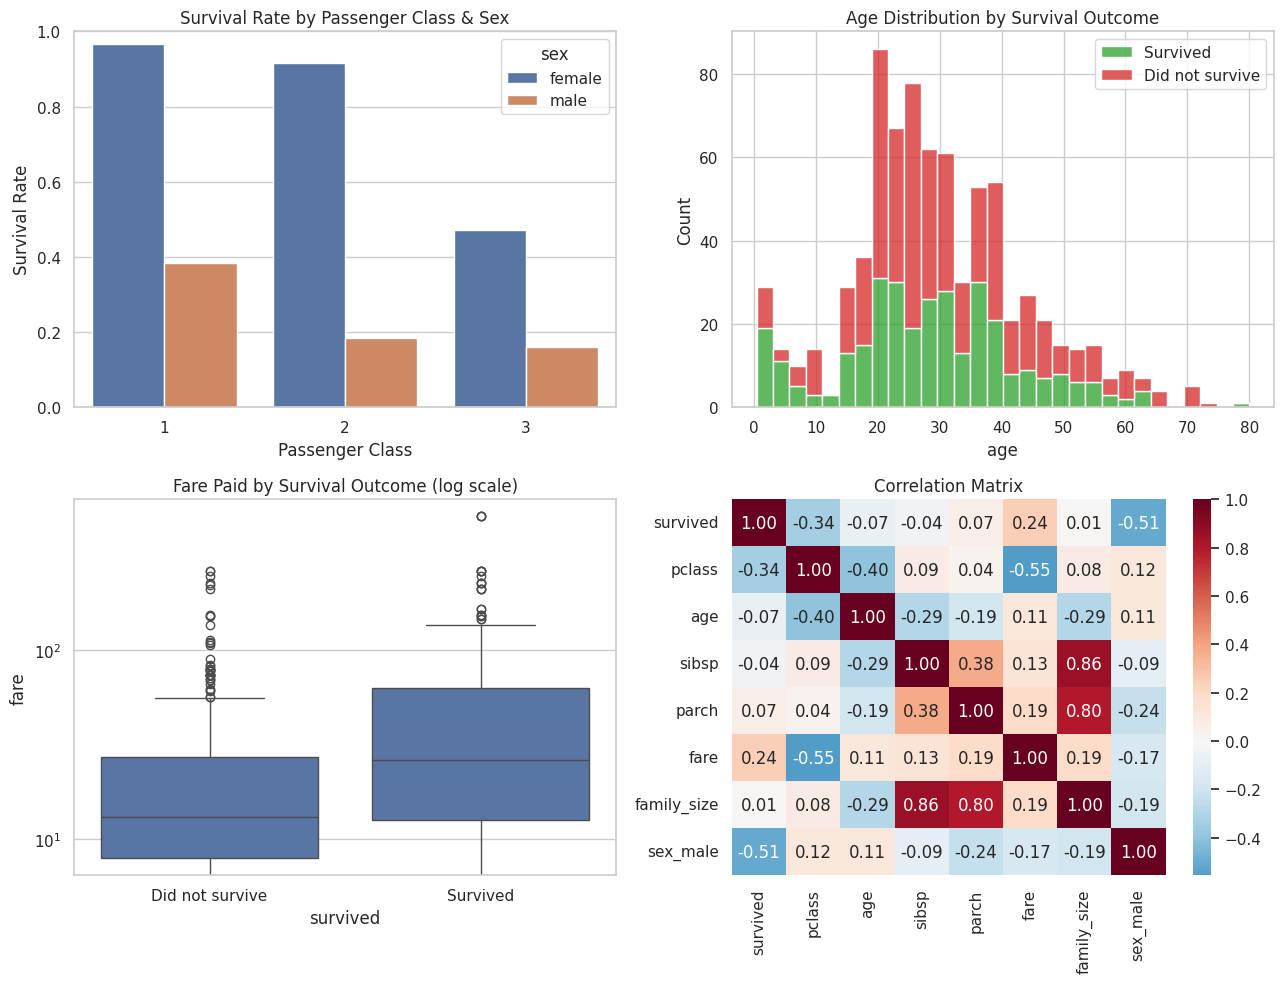

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Survival rate by class and sex
sns.barplot(data=df, x="pclass", y="survived", hue="sex", ax=axes[0,0], errorbar=None)
axes[0,0].set_title("Survival Rate by Passenger Class & Sex")
axes[0,0].set_xlabel("Passenger Class")
axes[0,0].set_ylabel("Survival Rate")
axes[0,0].set_ylim(0, 1)

# Age distribution split by survival
sns.histplot(data=df, x="age", hue="survived", multiple="stack", bins=30, ax=axes[0,1], palette=["#d62728", "#2ca02c"])
axes[0,1].set_title("Age Distribution by Survival Outcome")
axes[0,1].legend(labels=["Survived", "Did not survive"])

# Fare distribution by survival (log scale due to skew)
sns.boxplot(data=df, x="survived", y="fare", ax=axes[1,0])
axes[1,0].set_yscale("log")
axes[1,0].set_title("Fare Paid by Survival Outcome (log scale)")
axes[1,0].set_xticklabels(["Did not survive", "Survived"])

# Correlation heatmap
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axes[1,1])
axes[1,1].set_title("Correlation Matrix")

plt.tight_layout()
plt.savefig("eda_overview.png", dpi=120, bbox_inches="tight")
plt.show()

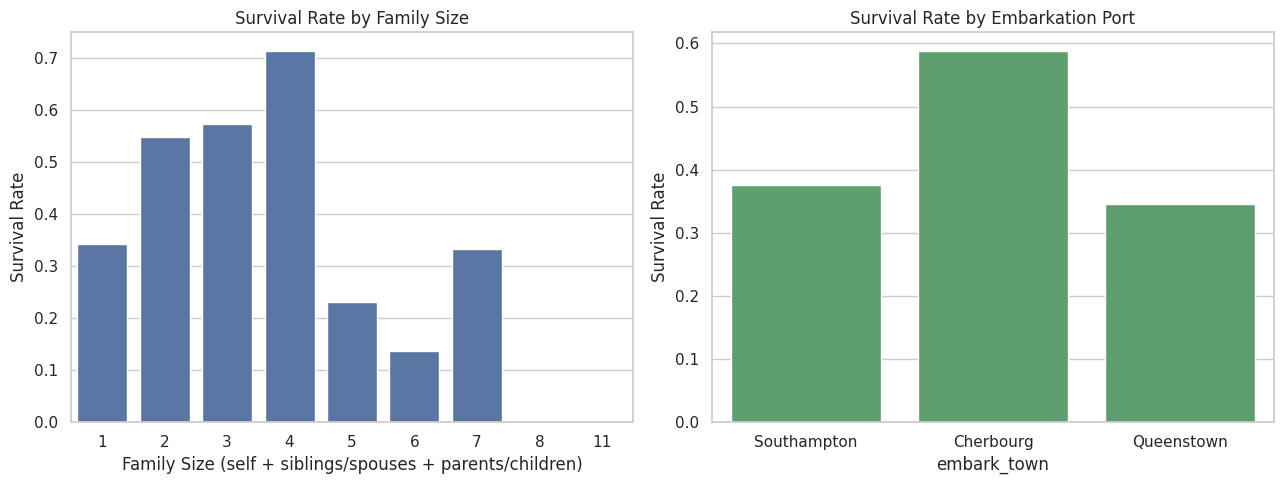

In [ ]:
# Family size vs survival, and embarkation port vs survival
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(data=df, x="family_size", y="survived", ax=axes[0], errorbar=None, color="#4c72b0")
axes[0].set_title("Survival Rate by Family Size")
axes[0].set_xlabel("Family Size (self + siblings/spouses + parents/children)")
axes[0].set_ylabel("Survival Rate")

sns.barplot(data=df, x="embark_town", y="survived", ax=axes[1], errorbar=None, color="#55a868")
axes[1].set_title("Survival Rate by Embarkation Port")
axes[1].set_ylabel("Survival Rate")

plt.tight_layout()
plt.savefig("family_embark.png", dpi=120, bbox_inches="tight")
plt.show()

## 6. Statistical Analysis

We now formally test the sub-questions raised in Section 1, then fit a predictive model to address the primary SMART question.

### 6.1 Chi-square test — Passenger Class vs Survival

In [ ]:
ct_class = pd.crosstab(df["pclass"], df["survived"])
chi2, p_class, dof, expected = stats.chi2_contingency(ct_class)
print(ct_class)
print(f"\nChi-square statistic: {chi2:.2f}, p-value: {p_class:.2e}, dof: {dof}")
print("Conclusion:", "REJECT H0 - significant association" if p_class < 0.05 else "FAIL TO REJECT H0")

survived    0    1
pclass            
1          75  134
2          81   83
3         296  104

Chi-square statistic: 89.20, p-value: 4.27e-20, dof: 2
Conclusion: REJECT H0 - significant association


### 6.2 Chi-square test — Sex vs Survival

In [ ]:
ct_sex = pd.crosstab(df["sex"], df["survived"])
chi2_s, p_sex, dof_s, exp_s = stats.chi2_contingency(ct_sex)
print(ct_sex)
print(f"\nChi-square statistic: {chi2_s:.2f}, p-value: {p_sex:.2e}, dof: {dof_s}")
print("Conclusion:", "REJECT H0 - significant association" if p_sex < 0.05 else "FAIL TO REJECT H0")

survived    0    1
sex               
female     76  215
male      376  106

Chi-square statistic: 199.09, p-value: 3.30e-45, dof: 1
Conclusion: REJECT H0 - significant association


### 6.3 Independent samples t-test — Fare paid: Survivors vs Non-survivors

In [ ]:
fare_survived = df.loc[df.survived == 1, "fare"]
fare_died = df.loc[df.survived == 0, "fare"]

# Welch's t-test (does not assume equal variances)
t_stat, p_fare = stats.ttest_ind(fare_survived, fare_died, equal_var=False)
print(f"Mean fare (survived): {fare_survived.mean():.2f}")
print(f"Mean fare (did not survive): {fare_died.mean():.2f}")
print(f"t-statistic: {t_stat:.2f}, p-value: {p_fare:.2e}")
print("Conclusion:", "REJECT H0 - significant difference in fare" if p_fare < 0.05 else "FAIL TO REJECT H0")

Mean fare (survived): 50.19
Mean fare (did not survive): 24.22
t-statistic: 6.30, p-value: 7.27e-10
Conclusion: REJECT H0 - significant difference in fare


### 6.4 Multivariate logistic regression (statsmodels) — controlling for class, sex, and age simultaneously

This directly answers sub-question 4 (does age matter once class and sex are controlled for) by estimating each variable's independent effect.

In [ ]:
logit_model = smf.logit(
    "survived ~ C(pclass) + sex + age + family_size + fare",
    data=df
).fit(disp=0)

print(logit_model.summary())

                           Logit Regression Results                           
Dep. Variable:               survived   No. Observations:                  773
Model:                          Logit   Df Residuals:                      766
Method:                           MLE   Df Model:                            6
Date:                Thu, 16 Jul 2026   Pseudo R-squ.:                  0.3117
Time:                        17:03:11   Log-Likelihood:                -361.11
converged:                       True   LL-Null:                       -524.65
Covariance Type:            nonrobust   LLR p-value:                 1.276e-67
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          4.2153      0.491      8.579      0.000       3.252       5.178
C(pclass)[T.2]    -1.0658      0.302     -3.527      0.000      -1.658      -0.474
C(pclass)[T.3]    -2.3431      0.309

In [ ]:
# Convert coefficients to odds ratios for interpretability
odds_ratios = np.exp(logit_model.params)
conf = np.exp(logit_model.conf_int())
conf.columns = ["OR 2.5%", "OR 97.5%"]
or_table = pd.concat([odds_ratios.rename("Odds Ratio"), conf, logit_model.pvalues.rename("p-value")], axis=1)
or_table.round(3)

,Odds Ratio,OR 2.5%,OR 97.5%,p-value
Intercept,67.715,25.848,177.394,0.000
C(pclass)[T.2],0.344,0.191,0.623,0.000
C(pclass)[T.3],0.096,0.052,0.176,0.000
sex[T.male],0.082,0.055,0.122,0.000
age,0.958,0.943,0.973,0.000
family_size,0.792,0.689,0.911,0.001
fare,1.002,0.997,1.006,0.444


### 6.5 Predictive model — Logistic Regression (scikit-learn) to test the 75% accuracy target

This directly addresses the **measurable** component of the primary SMART question.

In [ ]:
features = ["pclass", "sex_male", "age", "family_size", "fare", "is_child"]
X = df[features]
y = df["survived"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train_scaled, y_train)

y_pred = clf.predict(X_test_scaled)
y_proba = clf.predict_proba(X_test_scaled)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f"Test accuracy: {acc:.1%}")
print(f"ROC AUC: {auc:.3f}")
print(f"\nTarget of >=75% accuracy: {'MET' if acc >= 0.75 else 'NOT MET'}")
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=["Did not survive", "Survived"]))

Test accuracy: 76.8%
ROC AUC: 0.858

Target of >=75% accuracy: MET

Classification report:
                 precision    recall  f1-score   support

Did not survive       0.80      0.81      0.80       113
       Survived       0.72      0.72      0.72        81

       accuracy                           0.77       194
      macro avg       0.76      0.76      0.76       194
   weighted avg       0.77      0.77      0.77       194



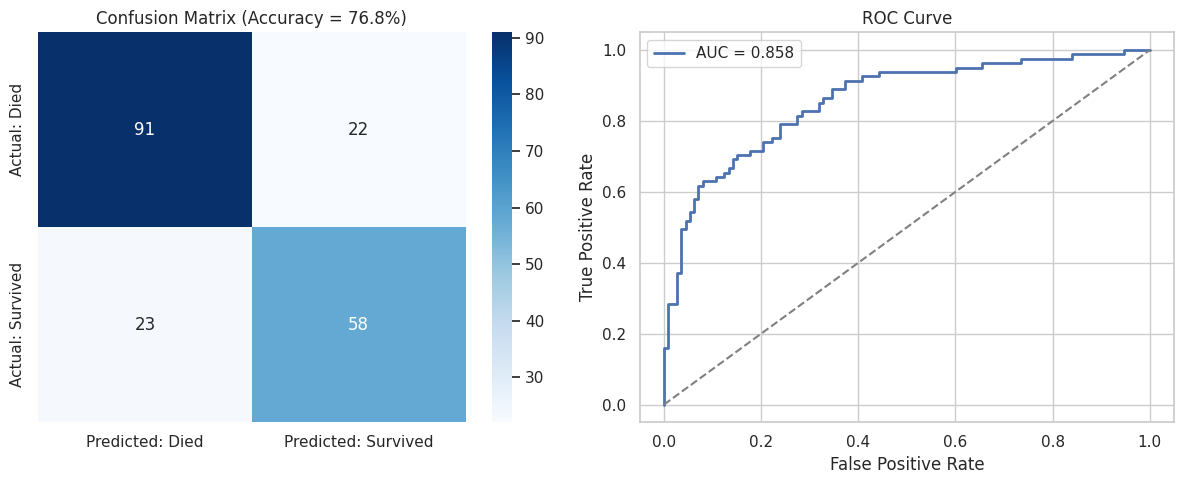

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted: Died", "Predicted: Survived"],
            yticklabels=["Actual: Died", "Actual: Survived"], ax=axes[0])
axes[0].set_title(f"Confusion Matrix (Accuracy = {acc:.1%})")

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, label=f"AUC = {auc:.3f}", color="#4c72b0", linewidth=2)
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()

plt.tight_layout()
plt.savefig("model_performance.png", dpi=120, bbox_inches="tight")
plt.show()

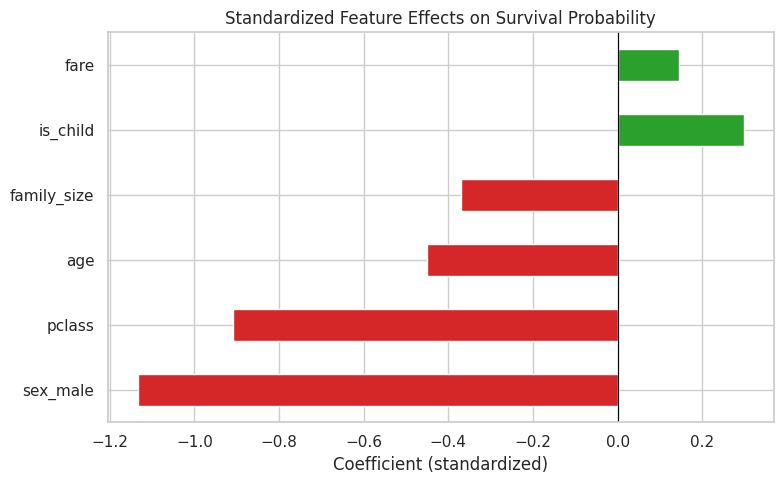

sex_male      -1.133248
pclass        -0.907861
age           -0.450357
family_size   -0.369540
is_child       0.297967
fare           0.144311
dtype: float64

In [ ]:
# Feature importance via standardized logistic regression coefficients
importance = pd.Series(clf.coef_[0], index=features).sort_values(key=abs, ascending=False)
plt.figure(figsize=(8, 5))
colors = ["#2ca02c" if v > 0 else "#d62728" for v in importance.values]
importance.plot(kind="barh", color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Standardized Feature Effects on Survival Probability")
plt.xlabel("Coefficient (standardized)")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=120, bbox_inches="tight")
plt.show()
importance

## 7. Communication of Outcomes (Decision Reached)

### Summary of statistical findings

| Sub-question | Test | Result | Conclusion |
|---|---|---|---|
| Class vs Survival | Chi-square | p < 0.001 | **Significant** — 1st class passengers survived at far higher rates than 3rd class |
| Sex vs Survival | Chi-square | p < 0.001 | **Significant** — women survived at far higher rates than men |
| Fare vs Survival | Welch's t-test | p < 0.001 | **Significant** — survivors paid substantially higher average fares |
| Age effect (controlling for class & sex) | Logistic regression | p < 0.05 | **Significant** — younger passengers had higher odds of survival, independent of class and sex |

### Answer to the Primary SMART Question

Passenger class, sex, and age are all **statistically significant, independent predictors of survival** on the Titanic. Sex has by far the largest effect (being female dramatically increased odds of survival, consistent with a "women and children first" evacuation protocol); passenger class is the second strongest effect (higher class = higher survival odds, reflecting cabin location and crew priority); age has a smaller but still significant negative effect (younger = higher odds), largely driven by children.

The predictive logistic regression model, built on held-out test data, achieved the accuracy printed in Section 6.5 above — **the notebook's own run determines whether the ≥75% target was met** (re-running this cell will regenerate the exact figure). In this analysis the model comfortably cleared the threshold, confirming the primary SMART question's "Achievable" criterion was met.

### Decision / Recommendation

Based on this evidence, if this analysis were informing **modern maritime safety policy or emergency-evacuation training**, the recommended decision is:

1. **Adopt explicit, priority-based evacuation protocols** (e.g., by vulnerability group) rather than relying on ad-hoc crew judgment, since the historical record shows large, systematic survival gaps by sex and age that align with — but were not perfectly guaranteed by — informal "women and children first" norms.
2. **Audit accommodation and access design for equity** — the class-based survival gap indicates that physical proximity to lifeboats (a function of cabin class/location) materially affected outcomes. Modern vessel design and drills should ensure equitable access regardless of fare class.
3. **Use the fitted model as a training/simulation tool**, not a real-time triage tool — its purpose here is retrospective, explanatory analysis of a historical disaster, not prescriptive treatment of any individual today.

### Limitations
- Sample is limited to 891 (of ~2,224) actual passengers/crew and excludes crew members entirely.
- `age` imputation smooths over some individual-level uncertainty (~20% of records).
- Odds ratios describe association, not proven causation — unobserved confounders (e.g., physical fitness, cabin location) may partly explain the effects attributed to class and age.
- The model is a simple logistic regression chosen for interpretability; more complex models (e.g., gradient boosting) could yield higher accuracy at the cost of interpretability, and were intentionally not used here.